# Market Factor Modeling & Statistical Arbitrage

This project studies whether low-rank PCA factors can separate common market movements from stock-specific residuals, and whether extreme residual deviations exhibit mean reversion.

The final strategy uses:

- rolling PCA factor estimation;
- PCA residual spreads;
- z-score entry signals;
- PCA-factor-neutral portfolio construction;
- a PC1 market-regime filter;
- transaction costs and turnover controls.

The goal is not to assume profitability, but to test when residual mean reversion is economically tradable and when it breaks down.

# Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_market_data
from src.pca import fit_pca
from src.backtest import run_backtest
from src.metrics import (
    equity_curve,
    drawdown_series,
    performance_summary
)

## 1. Data

In [2]:
prices, stock_returns, hedge_returns = load_market_data()

print("Number of stocks:", stock_returns.shape[1])
print("Number of trading days:", stock_returns.shape[0])

print(
    "Sample:",
    stock_returns.index.min().date(),
    "to",
    stock_returns.index.max().date()
)

stock_returns.tail()

Number of stocks: 20
Number of trading days: 1939
Sample: 2019-01-03 to 2026-09-21


Ticker,AAPL,MSFT,NVDA,GOOGL,META,JPM,BAC,GS,XOM,CVX,JNJ,PFE,WMT,COST,BA,CAT,KO,PEP,DIS,NFLX
Date,,,,,,,,,,,,,,,,,,,,
2026-09-15,-0.005224,-0.016403,0.005736,-0.012622,0.006971,0.006740,0.000841,-0.011918,0.025685,0.026394,0.003304,-0.006133,-0.009076,-0.019110,-0.002758,-0.000587,-0.001238,-0.006161,-0.019983,-0.030129
2026-09-16,0.003229,-0.013719,0.008154,-0.006116,0.004580,-0.010128,-0.027218,-0.039614,-0.035436,-0.028608,0.000299,-0.003267,-0.005458,-0.008443,-0.036864,-0.001047,-0.009469,-0.008561,0.005356,-0.019127
2026-09-17,0.013808,0.015195,0.025432,0.013008,0.013367,0.001118,0.004836,0.014382,-0.000306,0.000142,0.011000,0.006555,-0.006605,0.000213,-0.024559,0.020250,0.002162,-0.005062,-0.015329,-0.014396
2026-09-18,-0.002582,-0.007976,0.013358,0.006363,-0.024270,0.001031,-0.007735,-0.009953,0.001654,-0.009737,-0.000851,0.000724,-0.000562,0.001544,0.006091,0.013048,0.002158,-0.029253,-0.025439,-0.046740
2026-09-21,0.008479,0.015857,0.022990,0.015535,0.114285,0.006778,0.003984,0.018461,-0.032041,-0.027875,-0.001926,0.002892,0.006652,0.003541,0.014884,0.009283,-0.012805,-0.001233,0.015194,0.021869


## 2. PCA Market Structure

For centered stock returns \(X\), the sample covariance matrix is

$$
\Sigma = \frac{1}{T-1}X^\top X.
$$

Since $$(\Sigma)$$ is symmetric positive semidefinite, it admits an orthonormal eigendecomposition

$$
\Sigma = Q\Lambda Q^\top.
$$

The eigenvectors define principal market directions, while the eigenvalues measure return variance along those directions.

In [3]:
X = stock_returns.to_numpy()

(
    mean_returns,
    eigenvalues,
    eigenvectors,
    explained_variance_ratio,
    Q_k
) = fit_pca(
    X,
    k=6
)

cumulative_evr = np.cumsum(
    explained_variance_ratio
)

print(
    "PC1 explained variance:",
    explained_variance_ratio[0]
)

print(
    "Top 6 explained variance:",
    cumulative_evr[5]
)

PC1 explained variance: 0.41228977412519446
Top 6 explained variance: 0.7667128727423429


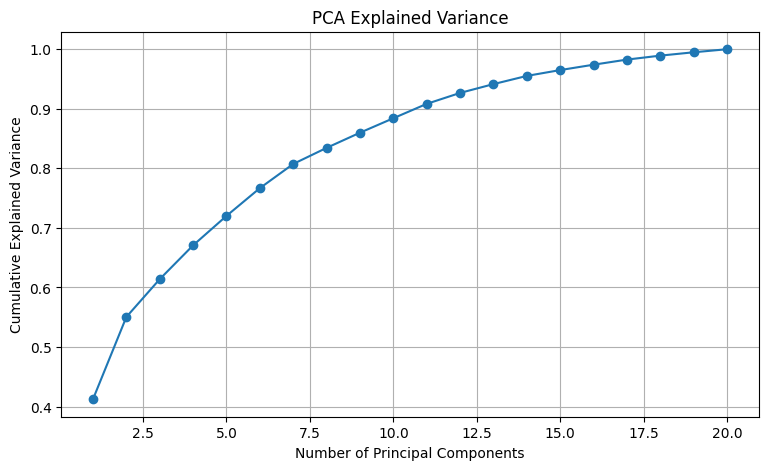

In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(
        1,
        len(cumulative_evr) + 1
    ),
    cumulative_evr,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()

### First Principal Component

The first principal component represents the direction of maximum cross-sectional return variance. Its loadings show which stocks contribute most strongly to the dominant common market movement.

In [5]:
pc1_loadings = pd.Series(
    eigenvectors[:, 0],
    index=stock_returns.columns,
    name="PC1 loading"
)

pc1_loadings.sort_values()

Ticker
JNJ      0.074947
WMT      0.090613
KO       0.096926
PFE      0.102581
PEP      0.103863
COST     0.127407
XOM      0.175211
CVX      0.200995
CAT      0.221920
MSFT     0.228382
DIS      0.229129
JPM      0.235088
GOOGL    0.236635
AAPL     0.239823
NFLX     0.240061
BAC      0.257834
GS       0.264012
META     0.295630
BA       0.334362
NVDA     0.390445
Name: PC1 loading, dtype: float64

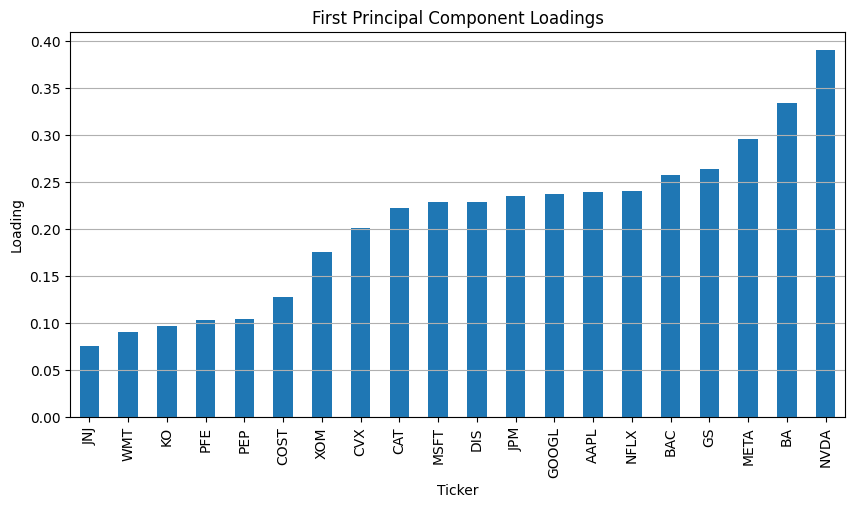

In [6]:
pc1_loadings.sort_values().plot(
    kind="bar",
    figsize=(10, 5),
    title="First Principal Component Loadings"
)

plt.ylabel("Loading")
plt.grid(axis="y")
plt.show()

## 3. PCA Residual Signal

For each centered daily return vector \(x_t\), the first \(k\) principal components define the common-factor projection

$$
\hat{x}_t = Q_k Q_k^\top x_t.
$$

The PCA residual is

$$
e_t = x_t - \hat{x}_t
    = (I - Q_k Q_k^\top)x_t.
$$

The residual therefore represents the component of the day's return that is orthogonal to the retained common PCA factors.

To measure persistent relative deviations, the strategy constructs a 40-day residual spread

$$
s_t = \sum_{j=0}^{39} e_{t-j}.
$$

The spread is standardized using a past-only rolling mean and standard deviation:

$$
z_t =
\frac{s_t-\mu_t}{\sigma_t}.
$$

Extreme negative spreads generate long candidates, while extreme positive spreads generate short candidates.

Since $$P_k = Q_kQ_k^\top$$ is an orthogonal projection,

$$
P_k^2=P_k,\qquad P_k^\top=P_k.
$$

Therefore,

$$
\hat{x}_t=P_kx_t,
\qquad
e_t=(I-P_k)x_t,
$$

and

$$
Q_k^\top e_t=0.
$$

## 4. Final Strategy

The final specification uses a z-score entry threshold of 2.5 and allows new positions only during high-PC1 regimes.

A high-PC1 regime is defined as a day when the current fraction of variance explained by PC1 exceeds the median of its previous 252 trading days.

In [7]:
results = run_backtest(
    stock_returns=stock_returns,

    pca_window=252,
    k=6,

    spread_window=40,

    signal_mode="zscore",
    z_window=252,
    entry_z=2.5,

    use_ar1_filter=False,

    use_pc1_regime_filter=True,
    regime_window=252,
    regime_quantile=0.50,

    max_holding=40,
    position_size=0.05,
    max_positions=10,

    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

performance = results["performance"]

performance_summary(performance)

Cumulative Return           0.035007
Annualized Volatility       0.010598
Sharpe Ratio                0.591791
Max Drawdown               -0.015430
Average Daily Turnover      0.007207
Total Transaction Costs     0.010054
Average Gross Exposure      0.075879
Average Active Positions    1.122581
dtype: float64

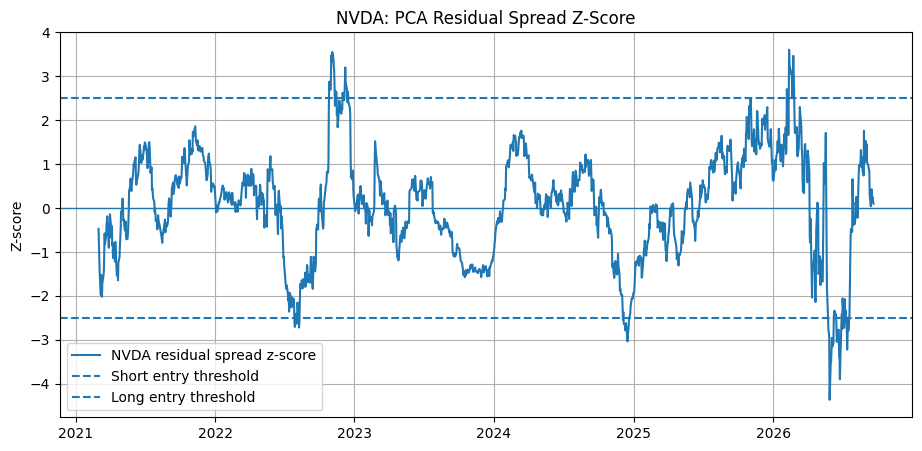

In [8]:
ticker = "NVDA"

zscores = results["zscores"]

plt.figure(figsize=(11, 5))

plt.plot(
    zscores.index,
    zscores[ticker],
    label=f"{ticker} residual spread z-score"
)

plt.axhline(
    2.5,
    linestyle="--",
    label="Short entry threshold"
)

plt.axhline(
    -2.5,
    linestyle="--",
    label="Long entry threshold"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(f"{ticker}: PCA Residual Spread Z-Score")
plt.ylabel("Z-score")
plt.legend()
plt.grid()

plt.show()

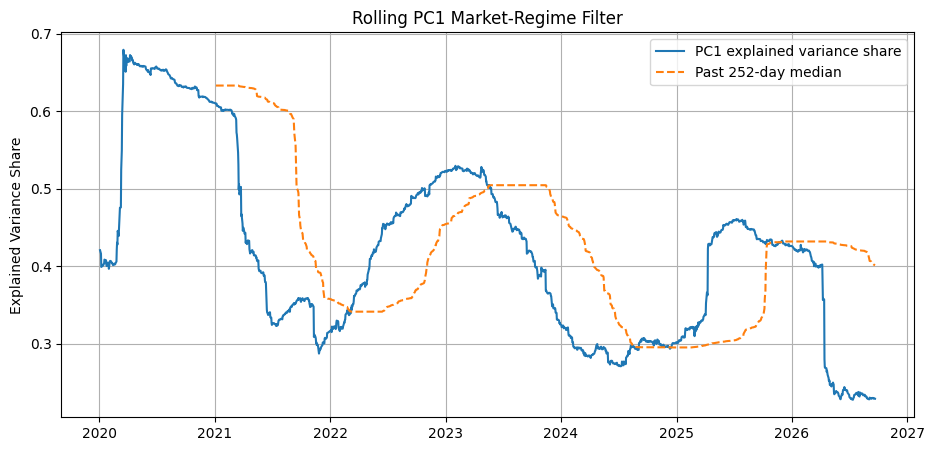

In [9]:
pc1_share = results["pc1_share"]
pc1_threshold = results["pc1_threshold"]

plt.figure(figsize=(11, 5))

plt.plot(
    pc1_share.index,
    pc1_share,
    label="PC1 explained variance share"
)

plt.plot(
    pc1_threshold.index,
    pc1_threshold,
    label="Past 252-day median",
    linestyle="--"
)

plt.title("Rolling PC1 Market-Regime Filter")
plt.ylabel("Explained Variance Share")
plt.legend()
plt.grid()

plt.show()

### Factor-Neutral Portfolio

Let $$w^{raw}$$ be the weights generated by the trading signals.

To remove exposure to the retained PCA factors, project the weights onto the orthogonal complement of the factor subspace:

$$
w =
(I-Q_kQ_k^\top)w^{raw}.
$$

Then

$$
Q_k^\top w
=
Q_k^\top(I-Q_kQ_k^\top)w^{raw}
=0,
$$

because

$$
Q_k^\top Q_k=I.
$$

Thus the portfolio has zero exposure to the retained PCA directions before gross-exposure scaling.

## 5. Strategy Performance

Portfolio value evolves according to

$$
V_{t+1} = V_t(1 + R_{t+1}^{net}),
$$

where net return includes transaction costs.

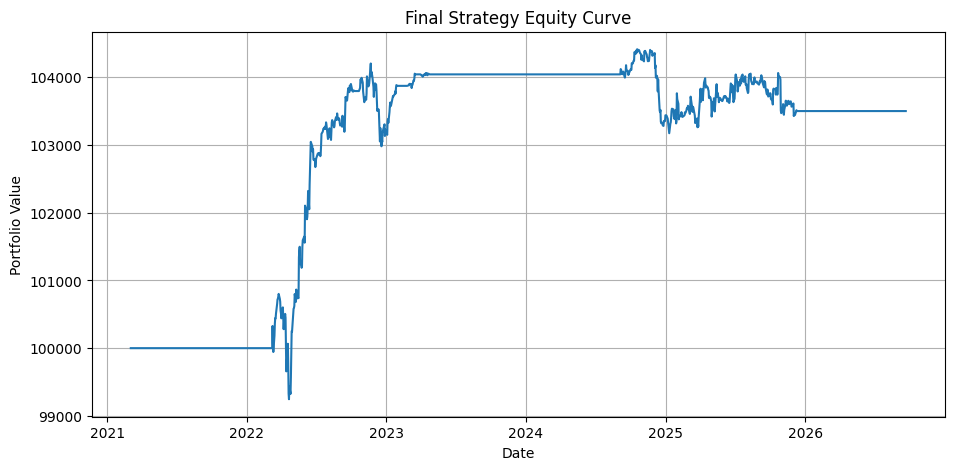

In [10]:
equity = equity_curve(
    performance["net_return"]
)

plt.figure(figsize=(11, 5))

plt.plot(equity)

plt.title("Final Strategy Equity Curve")
plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.grid()

plt.show()

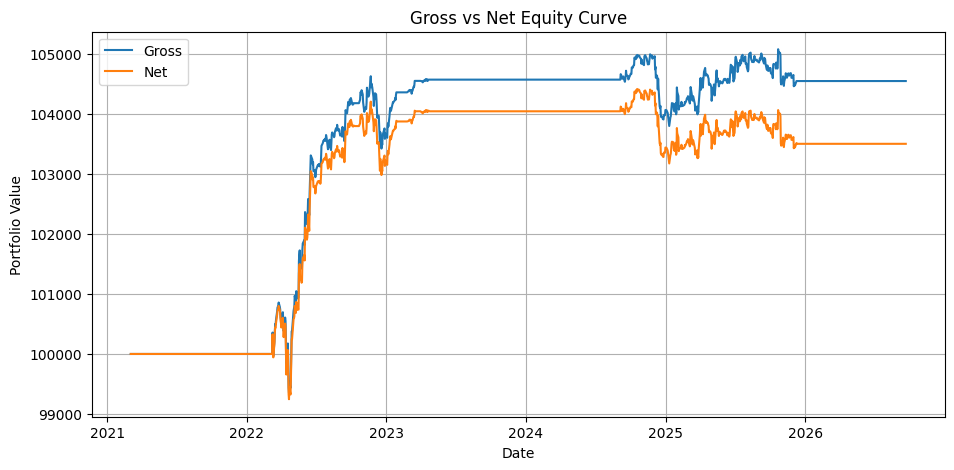

In [11]:
gross_equity = equity_curve(
    performance["gross_return"]
)

net_equity = equity_curve(
    performance["net_return"]
)

plt.figure(figsize=(11, 5))

plt.plot(
    gross_equity,
    label="Gross"
)

plt.plot(
    net_equity,
    label="Net"
)

plt.title("Gross vs Net Equity Curve")
plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.legend()
plt.grid()

plt.show()

### Drawdown

Drawdown measures the decline from the previous portfolio peak:

$$
D_t =
\frac{V_t - \max_{s \le t} V_s}
{\max_{s \le t} V_s}.
$$

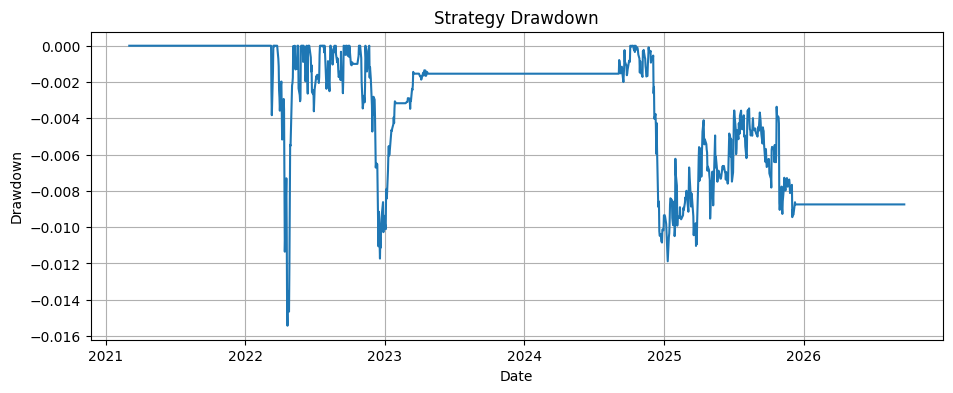

In [12]:
drawdown = drawdown_series(
    equity
)

plt.figure(figsize=(11, 4))

plt.plot(drawdown)

plt.title("Strategy Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid()

plt.show()

In [13]:
final_summary = performance_summary(
    performance
)

final_summary

Cumulative Return           0.035007
Annualized Volatility       0.010598
Sharpe Ratio                0.591791
Max Drawdown               -0.015430
Average Daily Turnover      0.007207
Total Transaction Costs     0.010054
Average Gross Exposure      0.075879
Average Active Positions    1.122581
dtype: float64

### Performance by Year

The strategy is evaluated separately by calendar year to examine regime dependence and stability over time.

In [14]:
yearly_rows = []

for year in sorted(
    performance.index.year.unique()
):

    year_perf = performance[
        performance.index.year == year
    ]

    summary = performance_summary(
        year_perf
    )

    yearly_rows.append({
        "year": year,

        "return":
            summary["Cumulative Return"],

        "sharpe":
            summary["Sharpe Ratio"],

        "max_drawdown":
            summary["Max Drawdown"],

        "avg_turnover":
            year_perf["turnover"].mean(),

        "avg_positions":
            year_perf["active_positions"].mean()
    })

yearly_results = pd.DataFrame(
    yearly_rows
)

yearly_results

,year,return,sharpe,max_drawdown,avg_turnover,avg_positions
0,2021,0.000000,NaN,0.000000,0.000000,0.000000
1,2022,0.032168,1.602018,-0.015430,0.017394,3.079681
2,2023,0.007999,2.274585,-0.000592,0.002771,0.208000
3,2024,-0.005812,-0.906341,-0.010847,0.003878,0.714286
4,2025,0.000608,0.053384,-0.006104,0.016075,2.244000
5,2026,0.000000,NaN,0.000000,0.000000,0.000000


## 6. Ablation Study

To isolate the contribution of the PCA regime filter, the final strategy is compared against the same strategy with the regime filter disabled.

All other parameters are held fixed.

In [15]:
baseline_results = run_backtest(
    stock_returns=stock_returns,

    pca_window=252,
    k=6,
    spread_window=40,

    signal_mode="zscore",
    z_window=252,
    entry_z=2.5,

    use_ar1_filter=False,

    use_pc1_regime_filter=False,

    max_holding=40,
    position_size=0.05,
    max_positions=10,

    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

baseline_perf = baseline_results["performance"]

regime_comparison = pd.DataFrame({
    "Baseline":
        performance_summary(
            baseline_perf
        ),

    "PC1 Regime Filter":
        performance_summary(
            performance
        )
})

regime_comparison

,Baseline,PC1 Regime Filter
Cumulative Return,-0.012443,0.035007
Annualized Volatility,0.015904,0.010598
Sharpe Ratio,-0.134274,0.591791
Max Drawdown,-0.044877,-0.015430
Average Daily Turnover,0.016863,0.007207
Total Transaction Costs,0.023524,0.010054
Average Gross Exposure,0.172864,0.075879
Average Active Positions,2.618638,1.122581


### Signal Threshold Comparison

A non-parametric alternative was also tested using empirical tail quantiles instead of z-scores.

The empirical thresholds avoid assuming a Gaussian residual-spread distribution, but they generated more trades and did not improve risk-adjusted performance.

In [16]:
quantile_results = run_backtest(
    stock_returns=stock_returns,

    pca_window=252,
    k=6,
    spread_window=40,

    signal_mode="quantile",
    z_window=252,

    lower_q=0.025,
    upper_q=0.975,

    use_ar1_filter=False,

    use_pc1_regime_filter=True,
    regime_window=252,
    regime_quantile=0.50,

    max_holding=40,
    position_size=0.05,
    max_positions=10,

    max_gross=0.50,
    cost_bps=10,
    rebalance_interval=20
)

quantile_perf = quantile_results["performance"]

signal_comparison = pd.DataFrame({
    "Z-score":
        performance_summary(
            performance
        ),

    "Empirical Quantiles":
        performance_summary(
            quantile_perf
        )
})

signal_comparison

,Z-score,Empirical Quantiles
Cumulative Return,0.035007,0.032431
Annualized Volatility,0.010598,0.015969
Sharpe Ratio,0.591791,0.369031
Max Drawdown,-0.015430,-0.033829
Average Daily Turnover,0.007207,0.017040
Total Transaction Costs,0.010054,0.023770
Average Gross Exposure,0.075879,0.153941
Average Active Positions,1.122581,2.658781


In [17]:
configs = [
    ("10x5_hold20", 10, 0.05, 20),
    ("10x5_hold40", 10, 0.05, 40),
    ("5x10_hold20", 5, 0.10, 20),
    ("5x10_hold40", 5, 0.10, 40),
]

rows = []

for name, max_pos, pos_size, holding in configs:

    r = run_backtest(
        stock_returns=stock_returns,

        pca_window=252,
        k=6,
        spread_window=40,

        signal_mode="zscore",
        z_window=252,
        entry_z=2.5,

        use_ar1_filter=False,

        use_pc1_regime_filter=True,
        regime_window=252,
        regime_quantile=0.50,

        max_holding=holding,
        position_size=pos_size,
        max_positions=max_pos,

        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = r["performance"]
    summary = performance_summary(perf)

    rows.append({
        "configuration": name,
        "return": summary["Cumulative Return"],
        "sharpe": summary["Sharpe Ratio"],
        "max_drawdown": summary["Max Drawdown"],
        "turnover": perf["turnover"].mean()
    })

portfolio_robustness = pd.DataFrame(rows)

portfolio_robustness

,configuration,return,sharpe,max_drawdown,turnover
0,10x5_hold20,0.023645,0.464661,-0.015443,0.008848
1,10x5_hold40,0.035007,0.591791,-0.015430,0.007207
2,5x10_hold20,0.039776,0.421337,-0.029094,0.016110
3,5x10_hold40,0.045883,0.462031,-0.022612,0.012574


### Residual-Horizon Sensitivity

The strategy is sensitive to the residual aggregation horizon \(H\).

This sensitivity is an important limitation: performance at \(H=40\) is substantially stronger than at nearby horizons, suggesting that part of the observed performance may be sample-specific rather than fully robust.

In [18]:
H_values = [30, 40, 50, 60]

rows = []

for H in H_values:

    r = run_backtest(
        stock_returns=stock_returns,

        pca_window=252,
        k=6,
        spread_window=H,

        signal_mode="zscore",
        z_window=252,
        entry_z=2.5,

        use_ar1_filter=False,

        use_pc1_regime_filter=True,
        regime_window=252,
        regime_quantile=0.50,

        max_holding=40,
        position_size=0.05,
        max_positions=10,

        max_gross=0.50,
        cost_bps=10,
        rebalance_interval=20
    )

    perf = r["performance"]
    summary = performance_summary(perf)

    rows.append({
        "H": H,
        "return": summary["Cumulative Return"],
        "sharpe": summary["Sharpe Ratio"],
        "max_drawdown": summary["Max Drawdown"]
    })

horizon_sensitivity = pd.DataFrame(rows)

horizon_sensitivity

,H,return,sharpe,max_drawdown
0,30,-0.002104,-0.033249,-0.023344
1,40,0.035007,0.591791,-0.015430
2,50,0.002429,0.045477,-0.024449
3,60,-0.002468,-0.034553,-0.031319


## 7. Conclusions

The main results are:

1. Stock returns have a clear low-rank structure. The first few PCA components explain a large part of total variance.

2. PCA residuals are obtained from

$$
e_t = (I-Q_kQ_k^\top)x_t,
$$

so they remove the common movements captured by the first \(k\) principal components.

3. A residual mean-reversion strategy without regime filtering performed poorly after transaction costs.

4. The PC1 regime filter improved the strategy. New trades were allowed only when

$$
PC1Share_t >
\operatorname{Median}
(PC1Share_{t-252},\ldots,PC1Share_{t-1}).
$$

5. The final specification reached approximately

$$
\text{Sharpe}=0.59,
\qquad
\text{Max Drawdown}=-1.54\%.
$$

6. Empirical quantile thresholds and an AR(1) filter did not improve the strategy.

7. Performance is very sensitive to the residual horizon \(H\). In particular, \(H=40\) performs much better than nearby values. This is an important limitation and suggests possible parameter overfitting.

The project therefore gives evidence that PCA residual mean reversion can depend strongly on market factor structure, but it does not establish a stable trading alpha.